In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(11)

employees = [f"emp_{i:02d}" for i in range(1, 16)]  # 15 employees
start_date = pd.Timestamp("2026-08-01")
num_weeks = 6

rows = []
task_id = 1
for emp in employees:
    base_tasks_per_week = np.random.randint(3, 12)
    base_hours = np.random.uniform(1, 6)

    for week in range(num_weeks):
        n_tasks = max(0, int(np.random.normal(base_tasks_per_week, 2)))
        for _ in range(n_tasks):
            week_start = start_date + pd.Timedelta(weeks=week)
            start = week_start + pd.Timedelta(days=np.random.randint(0, 5), hours=np.random.randint(8, 17))
            hours_taken = max(0.5, round(np.random.normal(base_hours, 1.5), 1))
            end = start + pd.Timedelta(hours=hours_taken)
            rows.append([f"task_{task_id:04d}", emp, week + 1, start, end, hours_taken])
            task_id += 1

tasks = pd.DataFrame(rows, columns=["task_id", "employee_id", "week", "start_time", "end_time", "hours_taken"])
print(tasks.shape)
tasks.head()

(677, 6)


,task_id,employee_id,week,start_time,end_time,hours_taken
0,task_0001,emp_01,1,2026-08-05 08:00:00,2026-08-05 11:48:00.000000000,3.8
1,task_0002,emp_01,1,2026-08-01 12:00:00,2026-08-01 16:36:00.000000000,4.6
2,task_0003,emp_01,2,2026-08-12 09:00:00,2026-08-12 13:05:59.999999999,4.1
3,task_0004,emp_01,2,2026-08-11 14:00:00,2026-08-11 18:24:00.000000000,4.4
4,task_0005,emp_01,2,2026-08-11 10:00:00,2026-08-11 15:00:00.000000000,5.0


In [3]:
print(tasks["week"].value_counts().sort_index())
print(tasks["hours_taken"].describe())

week
1    121
2    125
3    115
4    109
5    102
6    105
Name: count, dtype: int64
count    677.000000
mean       3.541802
std        1.870926
min        0.500000
25%        2.100000
50%        3.500000
75%        4.800000
max        8.900000
Name: hours_taken, dtype: float64


In [4]:
weekly_counts = tasks.groupby(["employee_id", "week"]).size().unstack(fill_value=0)
weekly_counts

week,1,2,3,4,5,6
employee_id,,,,,,
emp_01,2,6,2,4,2,3
emp_02,4,3,5,7,4,0
emp_03,10,10,10,6,7,10
emp_04,11,11,7,9,7,11
emp_05,10,9,12,9,10,10
emp_06,12,13,12,10,13,11
emp_07,7,5,3,6,0,1
emp_08,9,9,7,9,8,7
emp_09,10,4,7,8,9,6


In [5]:
struggling_emp = "emp_07"
mask = (tasks["employee_id"] == struggling_emp) & (tasks["week"] >= 5)
tasks.loc[mask, :] = tasks.loc[mask, :]  # placeholder, real change below

# Remove roughly 60% of this employee's tasks in weeks 5-6
drop_mask = mask & (np.random.rand(len(tasks)) < 0.6)
tasks = tasks[~drop_mask].reset_index(drop=True)

# Also make their remaining tasks in weeks 5-6 take noticeably longer
slow_mask = (tasks["employee_id"] == struggling_emp) & (tasks["week"] >=5)

print(tasks[tasks["employee_id"] == struggling_emp].groupby("week").size())

week
1    7
2    5
3    3
4    6
dtype: int64


In [6]:
weekly_counts = tasks.groupby(["employee_id", "week"]).size().unstack(fill_value=0)
weekly_counts.loc["emp_07"]

,emp_07
week,
1,7
2,5
3,3
4,6
5,0
6,0


In [7]:
avg_completion = tasks.groupby("employee_id")["hours_taken"].mean().round(1).rename("avg_hours_per_task")
avg_completion.sort_values(ascending=False)

,avg_hours_per_task
employee_id,
emp_14,6.0
emp_06,5.0
emp_01,4.5
emp_05,4.2
emp_08,4.1
emp_10,3.8
emp_03,3.4
emp_13,3.2
emp_12,3.2


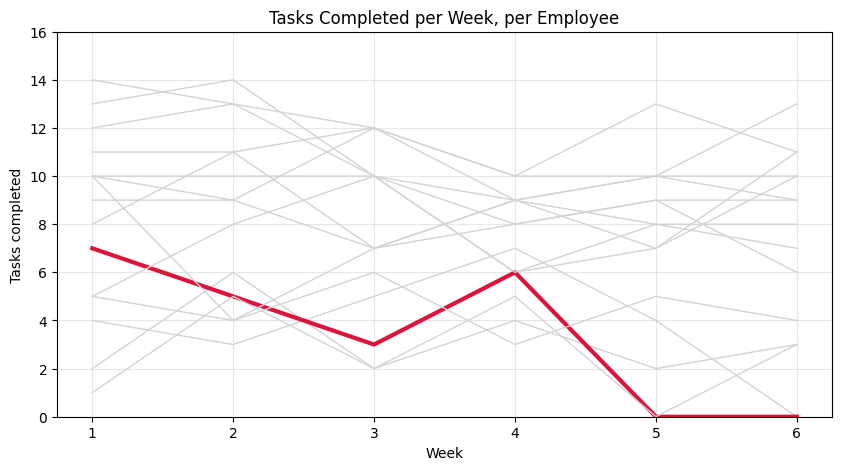

In [8]:
plt.figure(figsize=(10, 5))
for emp in weekly_counts.index:
    style = dict(linewidth=3, color="crimson") if emp == struggling_emp else dict(linewidth=1, color="lightgray")
    plt.plot(weekly_counts.columns, weekly_counts.loc[emp], **style)

plt.title("Tasks Completed per Week, per Employee")
plt.xlabel("Week")
plt.ylabel("Tasks completed")
plt.xticks(weekly_counts.columns)
plt.ylim(0, weekly_counts.values.max() + 2)
plt.grid(alpha=0.3)
plt.show()

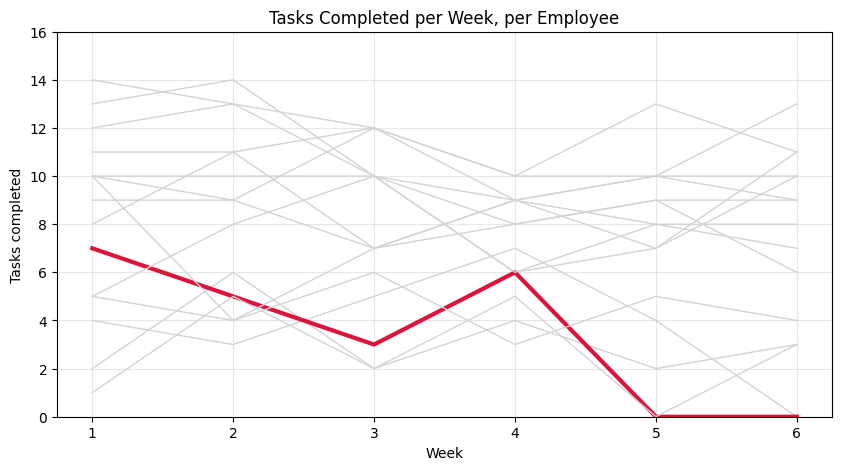

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
weekly_counts.to_csv("weekly_task_counts.csv")
avg_completion.sort_values(ascending=False).to_csv("avg_completion_time.csv")

plt.figure(figsize=(10, 5))
for emp in weekly_counts.index:
    style = dict(linewidth=3, color="crimson") if emp == struggling_emp else dict(linewidth=1, color="lightgray")
    plt.plot(weekly_counts.columns, weekly_counts.loc[emp], **style)
plt.title("Tasks Completed per Week, per Employee")
plt.xlabel("Week")
plt.ylabel("Tasks completed")
plt.xticks(weekly_counts.columns)
plt.ylim(0, weekly_counts.values.max() + 2)
plt.grid(alpha=0.3)
plt.savefig("weekly_trend_chart.png", dpi=150, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("weekly_task_counts.csv")
files.download("avg_completion_time.csv")
files.download("weekly_trend_chart.png")

In [10]:
import json
from google.colab import files

export = {
    "weeks": [int(w) for w in weekly_counts.columns],
    "employees": [
        {
            "employee_id": emp,
            "weekly_counts": [int(x) for x in weekly_counts.loc[emp]],
            "avg_hours": float(avg_completion[emp])
        }
        for emp in weekly_counts.index
    ],
    "struggling_employee": struggling_emp,
    "summary": "emp_07's average time per task is 2.4 hours, which is completely normal compared to the rest of the team. But their task count dropped to 0 in weeks 5 and 6, after averaging around 5-6 tasks a week before that. A manager looking only at the average-hours table would see nothing wrong. Only the weekly chart shows that emp_07 stopped completing tasks entirely."
}

with open("data.json", "w") as f:
    json.dump(export, f, indent=2)

files.download("data.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>